In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
raw_path = "../data/PCOS_data_without_infertility.xlsx"
df = pd.read_excel(raw_path, sheet_name="Full_new")
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [4]:
print("Shape:", df.shape)
df.info()


Shape: (541, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           5

In [5]:
# strip whitespace and standardize columns
df.columns = [c.strip().replace(" ", "_").replace("(", "").replace(")", "") for c in df.columns]
df.head()


,Sl._No,Patient_File_No.,PCOS_Y/N,Age_yrs,Weight_Kg,HeightCm,BMI,Blood_Group,Pulse_ratebpm,RR_breaths/min,Hbg/dl,CycleR/I,Cycle_lengthdays,Marraige_Status_Yrs,PregnantY/N,No._of_aborptions,I___beta-HCGmIU/mL,II____beta-HCGmIU/mL,FSHmIU/mL,LHmIU/mL,FSH/LH,Hipinch,Waistinch,Waist:Hip_Ratio,TSH_mIU/L,AMHng/mL,PRLng/mL,Vit_D3_ng/mL,PRGng/mL,RBSmg/dl,Weight_gainY/N,hair_growthY/N,Skin_darkening_Y/N,Hair_lossY/N,PimplesY/N,Fast_food_Y/N,Reg.ExerciseY/N,BP__Systolic_mmHg,BP__Diastolic_mmHg,Follicle_No._L,Follicle_No._R,Avg._F_size_L_mm,Avg._F_size_R_mm,Endometrium_mm,Unnamed:_44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [6]:
# Finding PCOS label column 
for col in df.columns:
    if "pcos" in col.lower():
        print("Detected PCOS column:", col)


Detected PCOS column: PCOS_Y/N


In [7]:
label_col = [c for c in df.columns if "pcos" in c.lower()][0]

df[label_col] = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)
df[label_col].value_counts()



PCOS_Y/N
0    364
1    177
Name: count, dtype: int64

In [8]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Sl._No,541.0,271.000000,156.317519,1.000000,136.000000,271.000000,406.000000,541.000000
Patient_File_No.,541.0,271.000000,156.317519,1.000000,136.000000,271.000000,406.000000,541.000000
PCOS_Y/N,541.0,0.327172,0.469615,0.000000,0.000000,0.000000,1.000000,1.000000
Age_yrs,541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.000000
Weight_Kg,541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.000000
HeightCm,541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.000000
BMI,541.0,24.311285,4.056399,12.417882,21.641274,24.238227,26.634958,38.900000
Blood_Group,541.0,13.802218,1.840812,11.000000,13.000000,14.000000,15.000000,18.000000
Pulse_ratebpm,541.0,73.247689,4.430285,13.000000,72.000000,72.000000,74.000000,82.000000
RR_breaths/min,541.0,19.243993,1.688629,16.000000,18.000000,18.000000,20.000000,28.000000


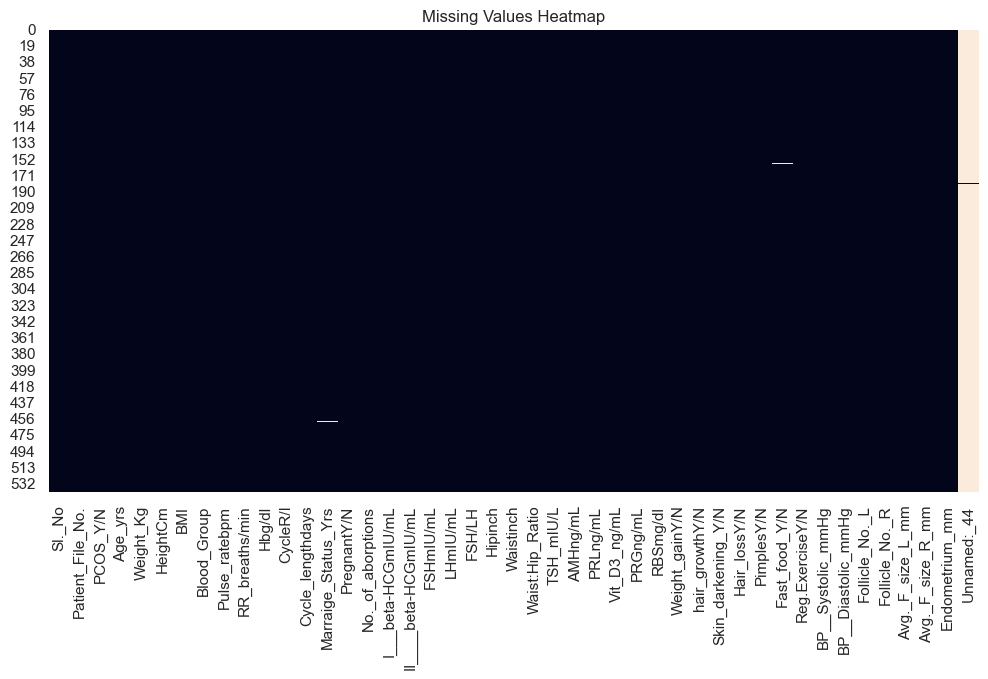

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [10]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Unnamed:_44            539
Fast_food_Y/N            1
Marraige_Status_Yrs      1
dtype: int64

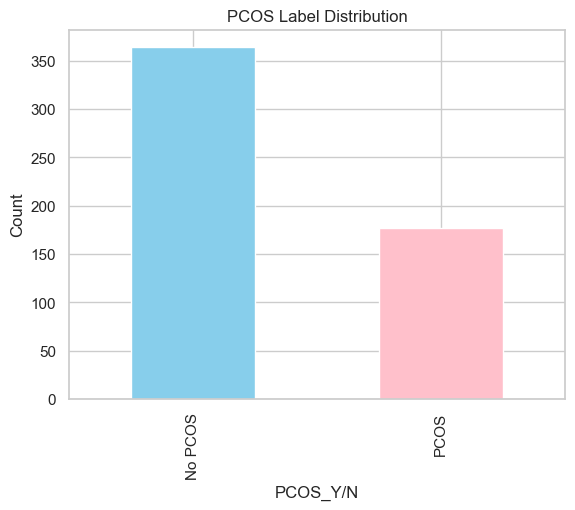

In [11]:
df[label_col].value_counts().plot(kind='bar', color=['skyblue', 'pink'])
plt.title("PCOS Label Distribution")
plt.xticks([0,1], ["No PCOS", "PCOS"])
plt.ylabel("Count")
plt.show()


In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", num_cols)


Numeric columns: ['Sl._No', 'Patient_File_No.', 'PCOS_Y/N', 'Age_yrs', 'Weight_Kg', 'HeightCm', 'BMI', 'Blood_Group', 'Pulse_ratebpm', 'RR_breaths/min', 'Hbg/dl', 'CycleR/I', 'Cycle_lengthdays', 'Marraige_Status_Yrs', 'PregnantY/N', 'No._of_aborptions', 'I___beta-HCGmIU/mL', 'FSHmIU/mL', 'LHmIU/mL', 'FSH/LH', 'Hipinch', 'Waistinch', 'Waist:Hip_Ratio', 'TSH_mIU/L', 'PRLng/mL', 'Vit_D3_ng/mL', 'PRGng/mL', 'RBSmg/dl', 'Weight_gainY/N', 'hair_growthY/N', 'Skin_darkening_Y/N', 'Hair_lossY/N', 'PimplesY/N', 'Fast_food_Y/N', 'Reg.ExerciseY/N', 'BP__Systolic_mmHg', 'BP__Diastolic_mmHg', 'Follicle_No._L', 'Follicle_No._R', 'Avg._F_size_L_mm', 'Avg._F_size_R_mm', 'Endometrium_mm']


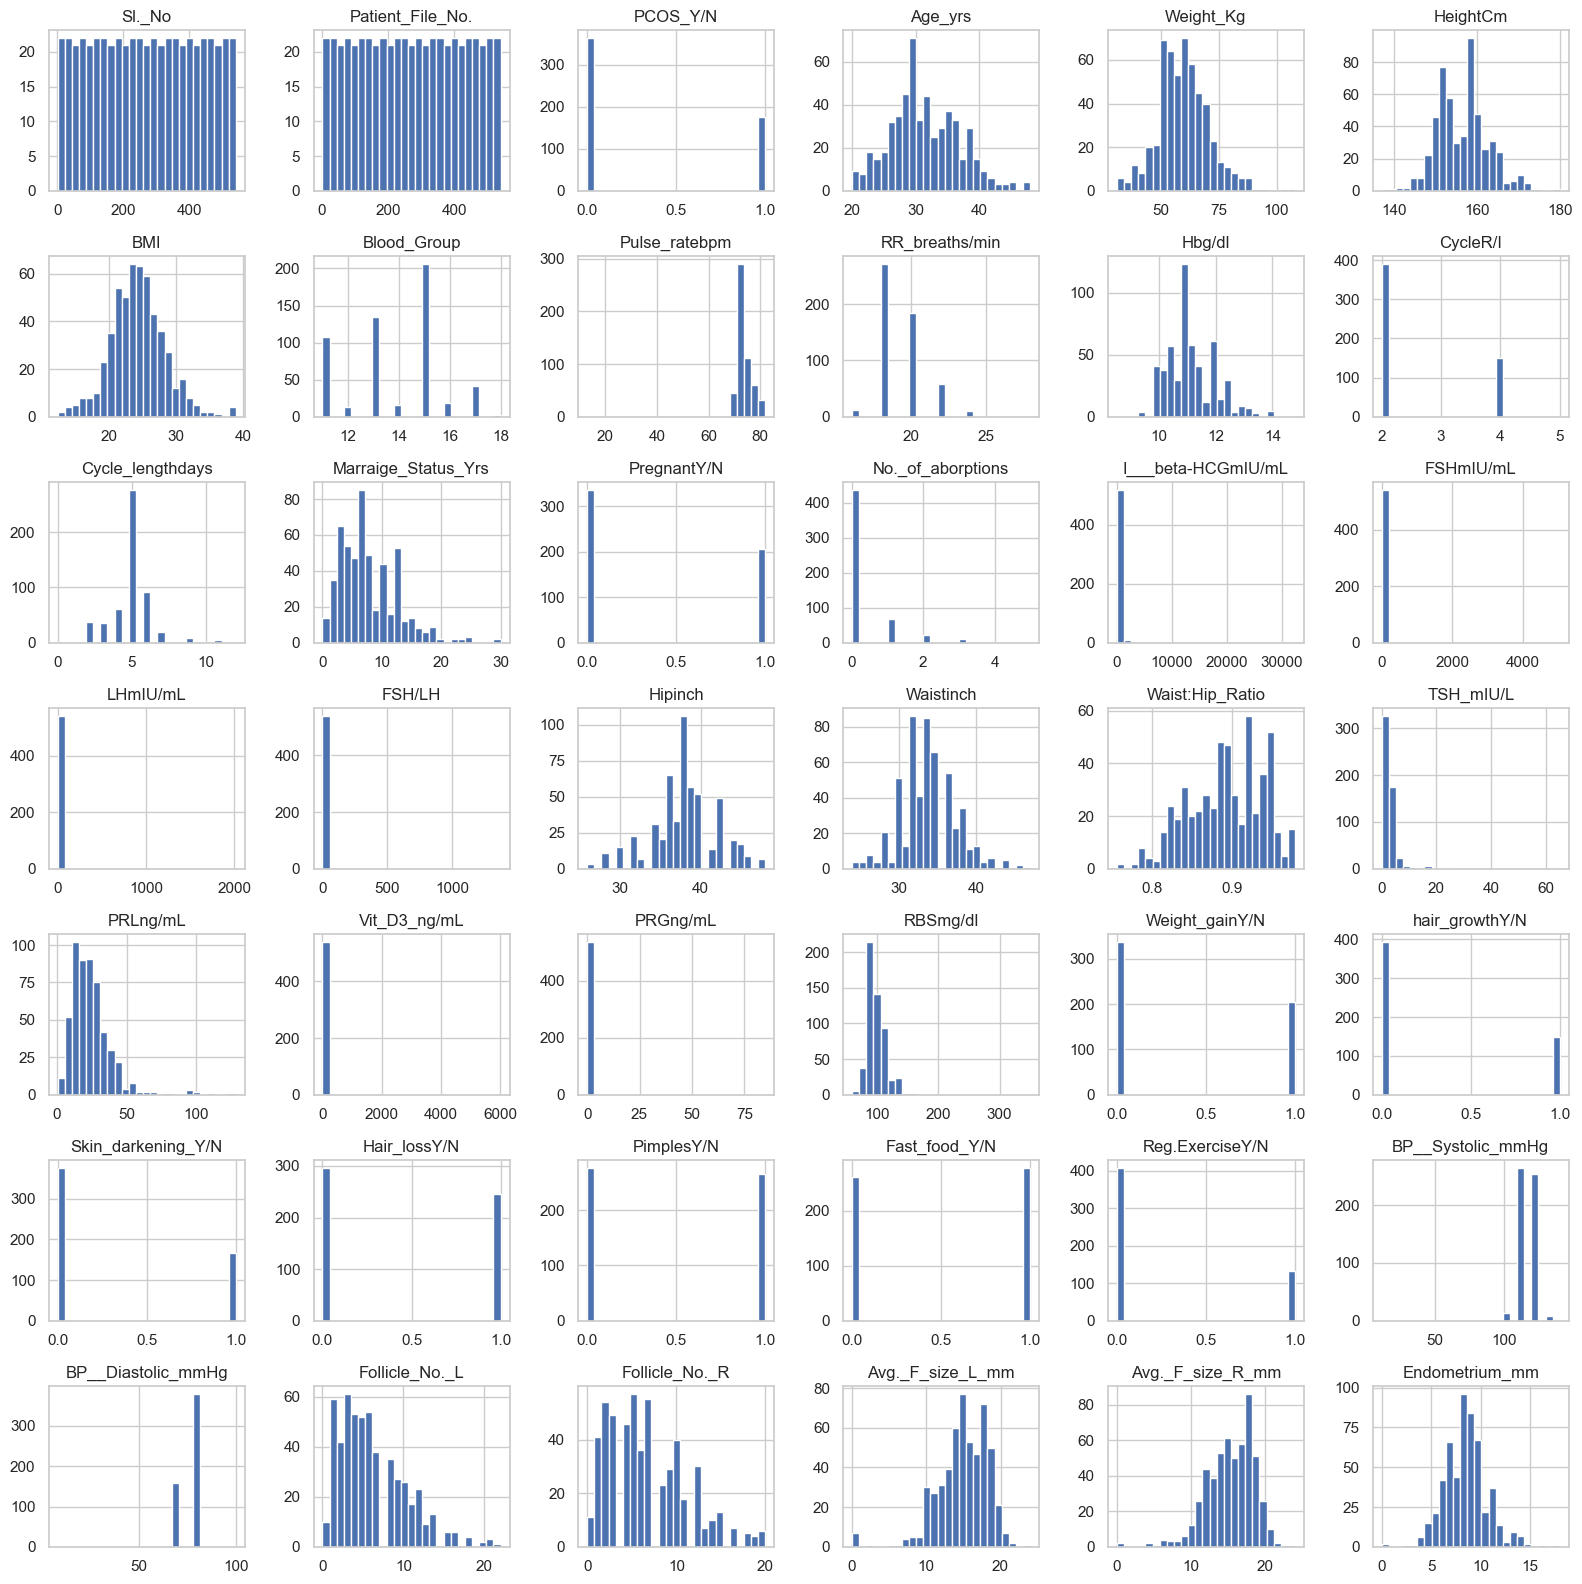

In [13]:
df[num_cols].hist(figsize=(16, 16), bins=25)
plt.tight_layout()
plt.show()


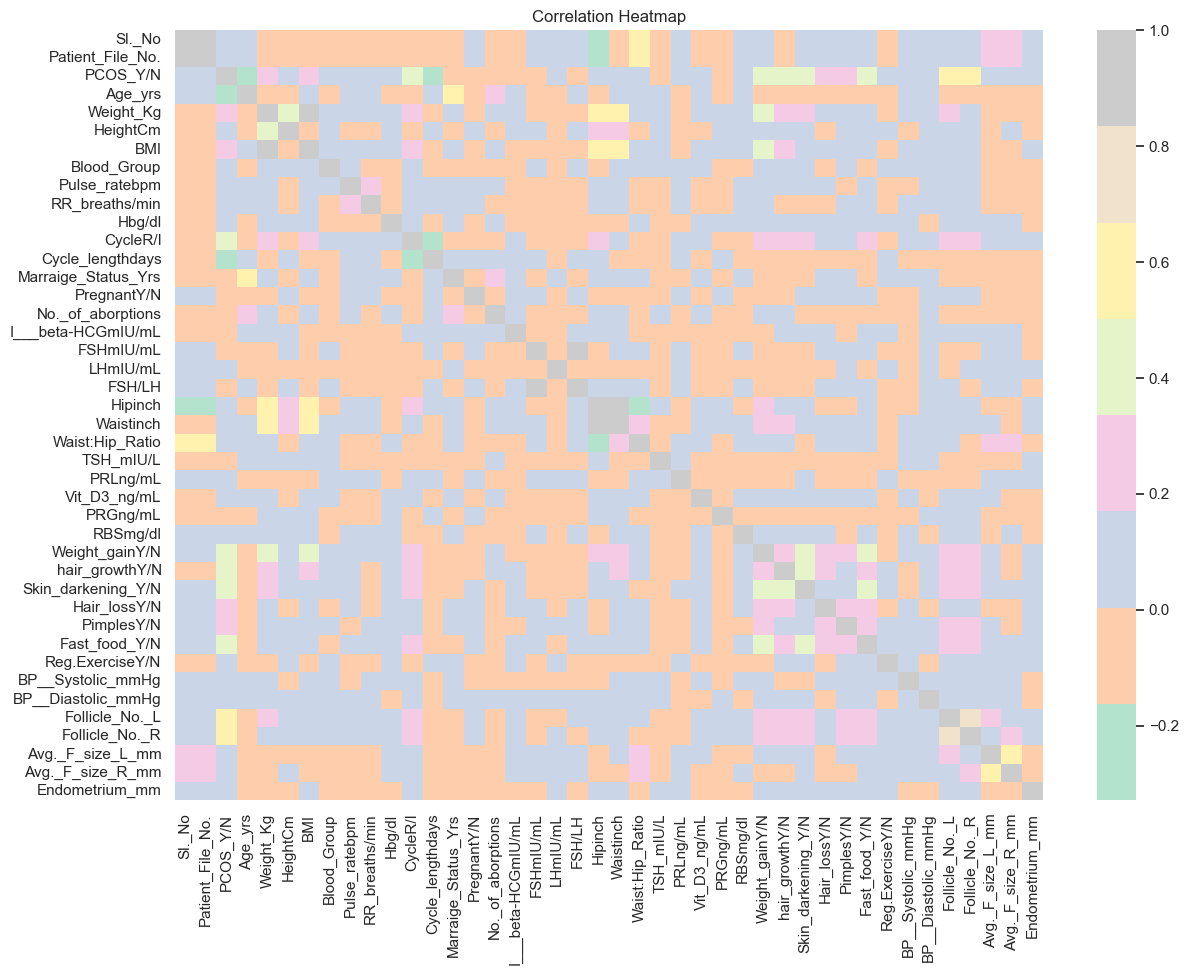

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), cmap="Pastel2", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [15]:
corr = df[num_cols].corr()[label_col].sort_values(ascending=False)
corr

PCOS_Y/N               1.000000
Follicle_No._R         0.648327
Follicle_No._L         0.603346
Skin_darkening_Y/N     0.475733
hair_growthY/N         0.464667
Weight_gainY/N         0.441047
CycleR/I               0.401644
Fast_food_Y/N          0.377933
PimplesY/N             0.286077
Weight_Kg              0.211938
BMI                    0.199534
Hair_lossY/N           0.172879
Waistinch              0.164598
Hipinch                0.162297
Avg._F_size_L_mm       0.132992
Endometrium_mm         0.106648
Avg._F_size_R_mm       0.097690
Pulse_ratebpm          0.091821
Hbg/dl                 0.087170
Vit_D3_ng/mL           0.085494
HeightCm               0.068254
Reg.ExerciseY/N        0.065337
LHmIU/mL               0.063879
Patient_File_No.       0.060998
Sl._No                 0.060998
RBSmg/dl               0.048922
BP__Diastolic_mmHg     0.038032
RR_breaths/min         0.036928
Blood_Group            0.036433
Waist:Hip_Ratio        0.012386
BP__Systolic_mmHg      0.007942
PRLng/mL

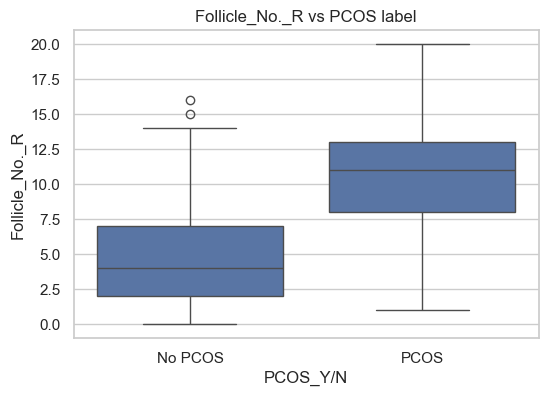

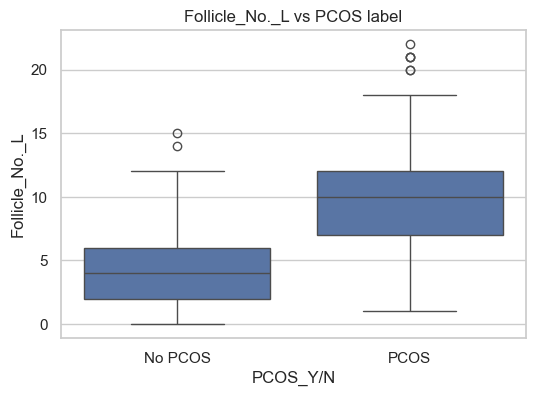

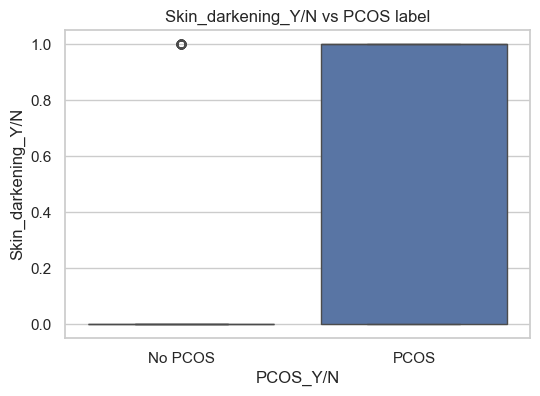

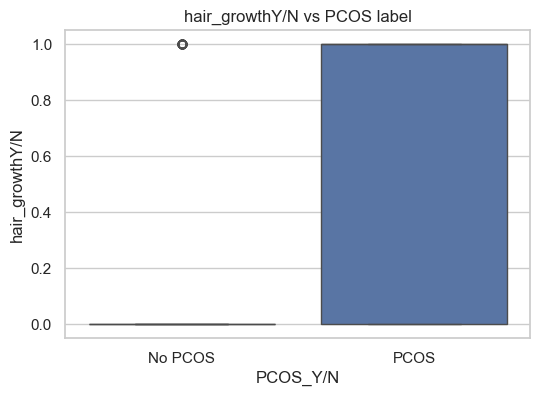

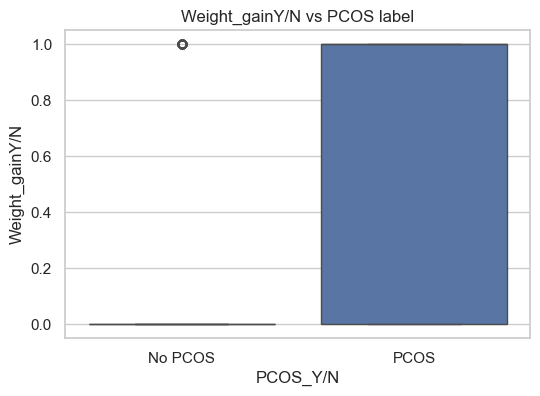

In [16]:
# Choose the top 5 strongest correlations (ignore the label itself)
top_features = corr.drop(label_col).abs().sort_values(ascending=False).head(5).index.tolist()

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[label_col], y=df[col])
    plt.title(f"{col} vs PCOS label")
    plt.xticks([0,1], ["No PCOS", "PCOS"])
    plt.show()


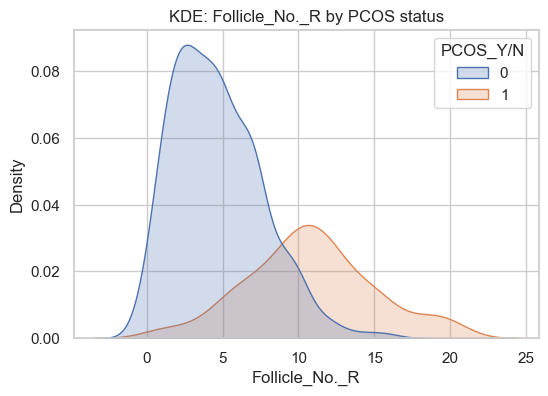

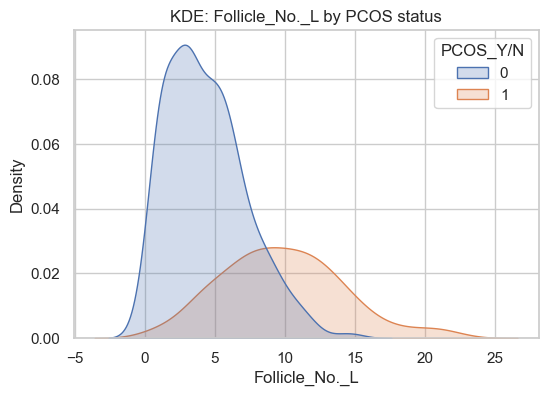

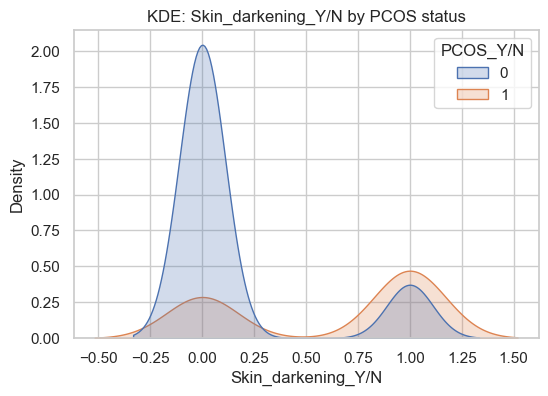

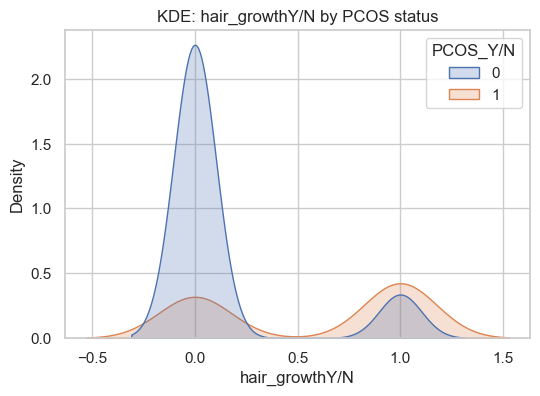

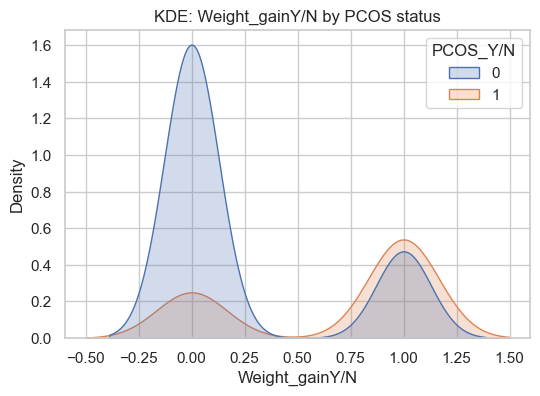

In [17]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue=label_col, fill=True)
    plt.title(f"KDE: {col} by PCOS status")
    plt.show()


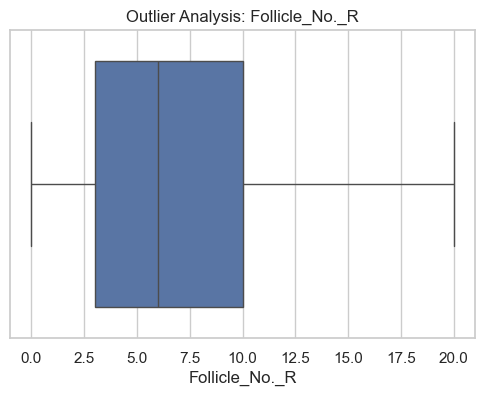

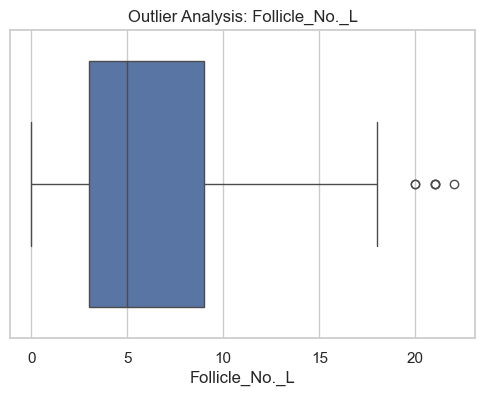

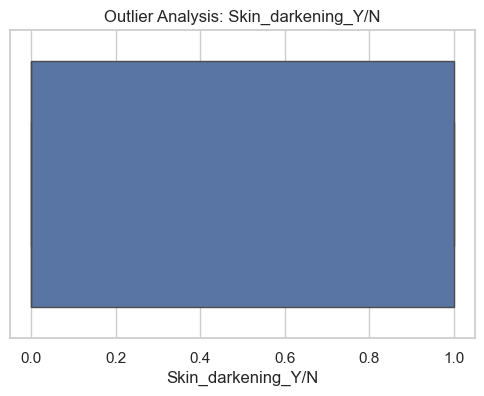

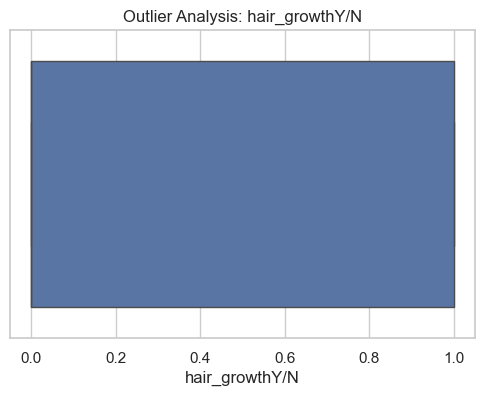

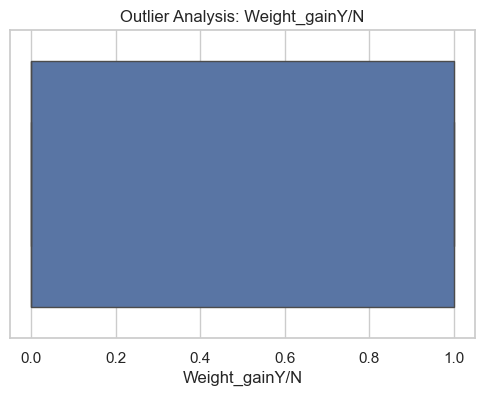

In [18]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Analysis: {col}")
    plt.show()


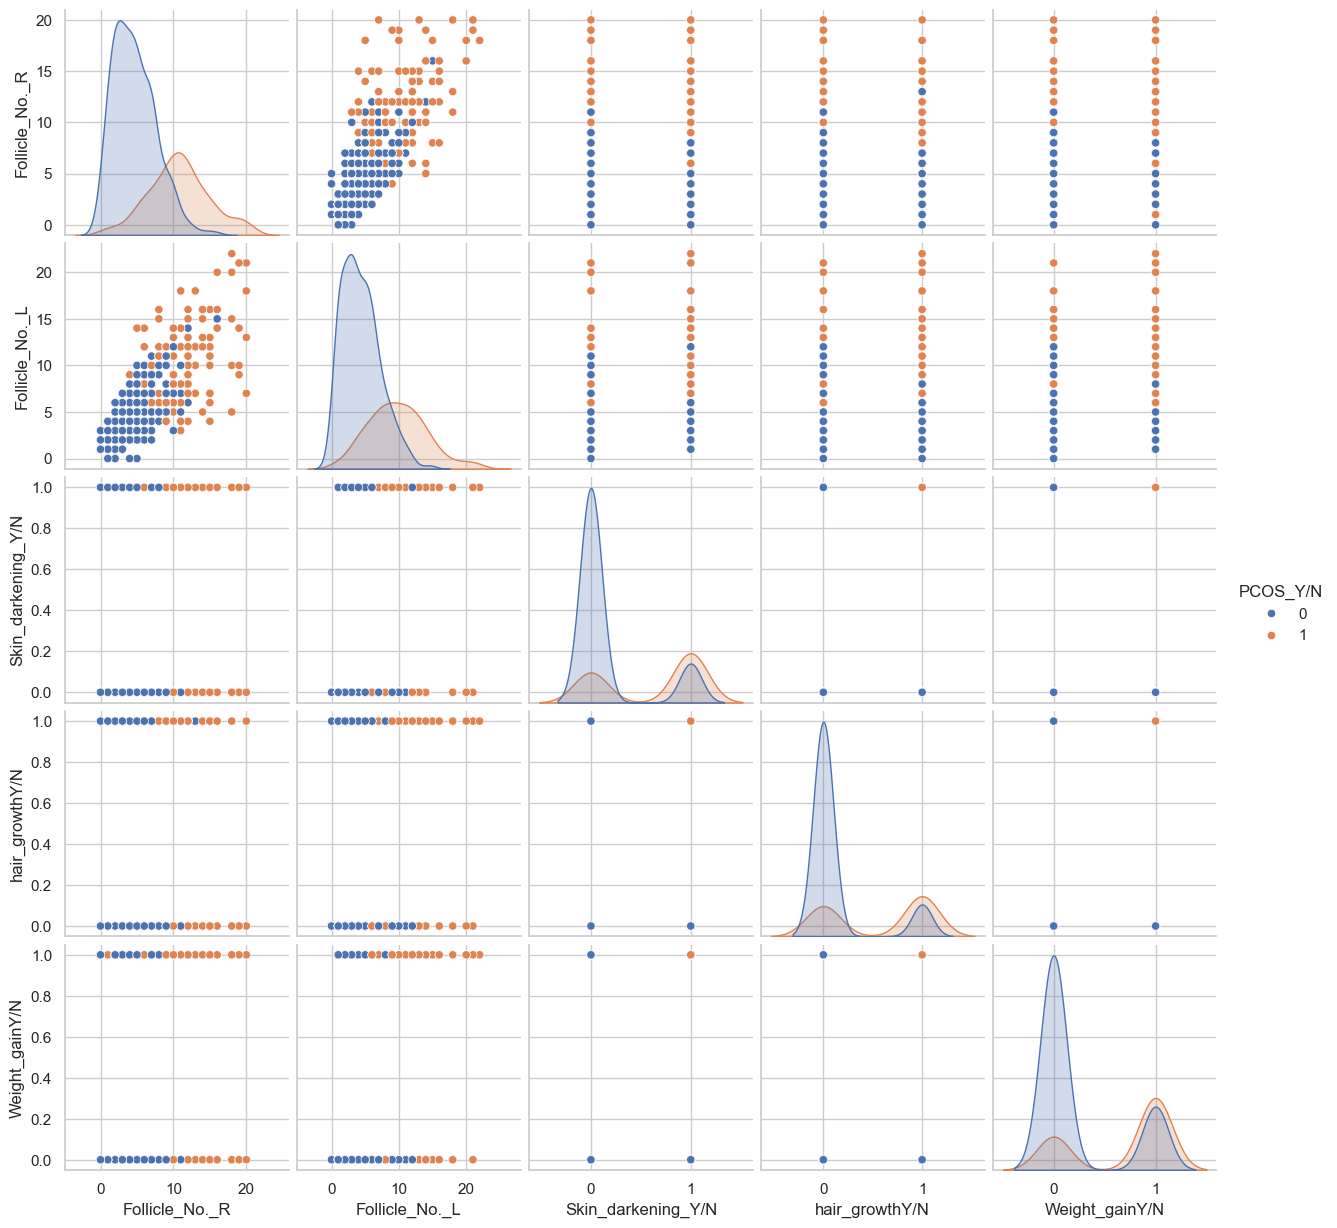

In [19]:
sns.pairplot(df[top_features + [label_col]].dropna(), hue=label_col)
plt.show()

In [20]:
clean_path = "../data/processed/pcos_cleaned_eda.csv"
df.to_csv(clean_path, index=False)
clean_path


'../data/processed/pcos_cleaned_eda.csv'